# Estimation for Joint Recovery of $p$ and $\theta$

We aim to jointly estimate the initial-condition parameters $p$ and the dynamic parameters $\theta = (\phi, \gamma)$ using only the final observation $h(T,x)$. The forward model is governed by the PDE

$$
\frac{\partial h(t,x)}{\partial t}
= C_0\, g(\phi; t)\, \frac{\partial}{\partial x}\big( u(\gamma; t, x)\, h(t,x)\big),
$$

with the initial condition represented by a Gaussian mixture

$$
h(0,x) = f(p).
$$

The inverse problem is formulated as the minimization of the regularized objective functional

$$
J(p,\theta)
=
\frac{1}{2}\,\|\,y - \mathcal{F}(p,\theta)\,\|_{W}^2
\;+\;
\lambda_p\, R_p(p)
\;+\;
\lambda_{\theta}\, R_{\theta}(\theta),
$$

where $y$ is the observed final state, $\mathcal{F}(p,\theta)$ is the forward PDE solution at $t=T$, and $R_p$, $R_\theta$ are regularization terms.

### Iniciar Ray 
```bash
ray start --head --dashboard-host=0.0.0.0 --node-ip-address=0.0.0.0
```



In [13]:
import os


os.environ["RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO"] = "0"
os.environ["RAY_DEDUP_LOGS"] = "1"

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from starforge.blackholes.parameters_recover.parameters_recovery import ParametersRecoveryRemote
from starforge.blackholes.parameters_recover.metrics import (
    nrmse_percent,
    smape_percent,
    stabilized_mape_percent,
)
from starforge.blackholes.accretionrate.blackholesaccretionrate import ParameterAccretionRate
from starforge.blackholes.parameters_recover.utils import add_noise_to_data, gaussian_sum_from_p
from starforge.blackholes.parameters_recover.utils import make_bounds_for_gaussians
from starforge.blackholes.parameters_recover.schemes import GridParameters
import ray

In [15]:
if ray.is_initialized() is False:
    ray.init(ignore_reinit_error=True)

2026-05-21 10:51:45,767	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


In [16]:
mbh_steps = 25

grid_params = GridParameters(
    mbh_steps=mbh_steps,
    z_steps=mbh_steps*100
)

ln_mbh_grid = np.linspace(
    grid_params.mbh_i,
    grid_params.mbh_f,
    grid_params.mbh_steps
)

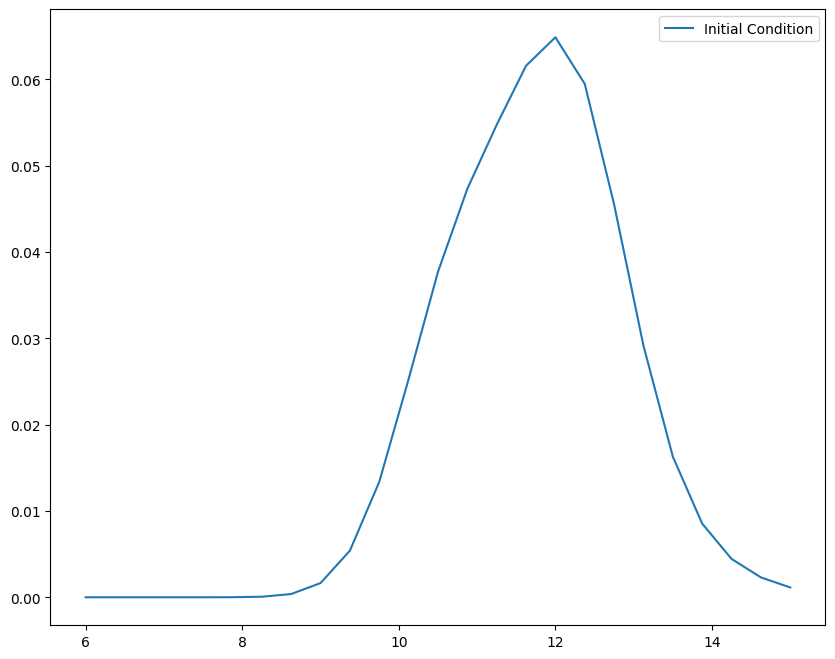

In [17]:
parameters_observational = np.array([
        3.3e-02,
        8.2e-03,
        5.4e-02,
        1.07e+01,
        1.29e+01,
        1.21e+01,
        6.93e-01,
        1.05e+00,
        7.47e-01
    ])


initial_condition = gaussian_sum_from_p(
        parameters_observational,
        ln_mbh_grid,
        n_gauss=3
    )

plt.figure(figsize=(10,8))
plt.plot(ln_mbh_grid, initial_condition, label="Initial Condition")
# plt.yscale("log")
plt.legend()
plt.show()
plt.close()

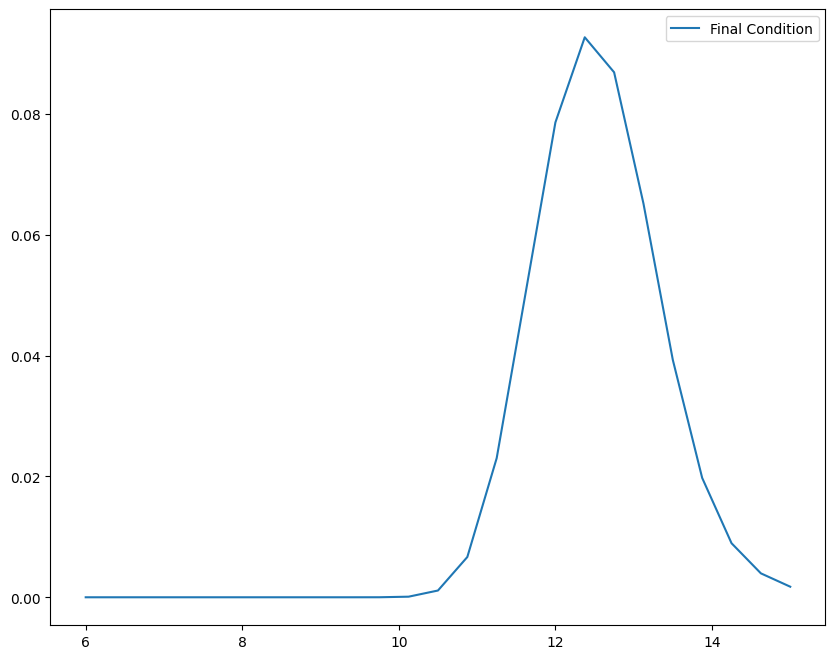

In [18]:
objective_function = ParametersRecoveryRemote.remote(
    grid_params=grid_params)

accretion_params = ParameterAccretionRate(
    mbh_par=2e11,
    alpha_par=3e-1,
    tau_par=5e9,
    eta=0.1,
    t_q=1e9,
    b_1=0.1,
    b_2=0.1,
)


# ---- Generate target data ----

outputs = ray.get(
    objective_function.directly_problem.remote(
        initial_condition,
        accretion_params
    )
)

noise_level = 0.01
  # 10% noise

target_data = add_noise_to_data(
    data=outputs.n_final,
    mu=0.0,
    sigma=noise_level,
    rho=0.5,
    alpha=0.5,
    seed=52,
    noise_type='mixed'
)

plt.figure(figsize=(10,8))
plt.plot(ln_mbh_grid, outputs.n_final, label="Final Condition")
# plt.yscale("log")
plt.legend()
plt.show()
plt.close()


In [19]:
initial_parameters = np.abs(np.random.randn(16))

# bounds = tuple([(0.001, 15) for _ in range(16)])  # 9 for gaussians, 7 for physical params

# ---- Define bounds for optimization ----

bounds = make_bounds_for_gaussians(
    x_min=6.0,
    x_max=15.0,
    preferred_center_index=2,
    preferred_center=12.0,
    preferred_center_radius=1.0,
    Amax=1e-1,
    sigma_min=0.01,
    sigma_max=5.0,
    sigma_max_preferred=1.0,
    K=3
)


bounds.extend([  # For eta, tau_par, alpha_par
    (0.5, 5.0),     # mbh_par
    (1.0, 10.0),   # tau_par Gyr
    (0.01, 0.6),    # alpha_par
    (0.01, 0.5),    # eta
    (0.5, 5.0),    # t_q Gyr
    (0.01, 0.5),   # b_1
    (0.01, 0.5)    # b_2
])

result = ray.get(
    objective_function.optimizer.remote(
        bounds=bounds,
        target_data=target_data,
        weight_p=0.01,
        weight_theta=0.01,
        fast_mode=False,
        use_de=True
    )
)

print("Optimized Parameters:", result)

(ParametersRecovery pid=525847) Starting optimization ...
(ParametersRecovery pid=525847) Objective value: 1.446077e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=525847) Objective value: 1.428702e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=525847) Objective value: 1.398453e+02 | Context: Minimum detected in annealing process


(ParametersRecovery pid=525847) /home/eduardo/Projects/starforge2/.venv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
(ParametersRecovery pid=525847)   df = [f_eval - f0 for f_eval in f_evals]


(ParametersRecovery pid=525847) Objective value: 1.381031e+02 | Context: Detection occurred in local search
(ParametersRecovery pid=525847) Objective value: 1.098651e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=525847) Objective value: 1.020530e+02 | Context: Minimum detected in annealing process
(ParametersRecovery pid=525847) Objective value: 9.062379e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=525847) Objective value: 8.938044e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=525847) Objective value: 8.405897e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=525847) Objective value: 8.405867e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=525847) Objective value: 8.405273e+01 | Context: Minimum detected in annealing process
(ParametersRecovery pid=525847) Objective value: 8.404704e+01 | Context: Minimum detected in annealing process
(Par

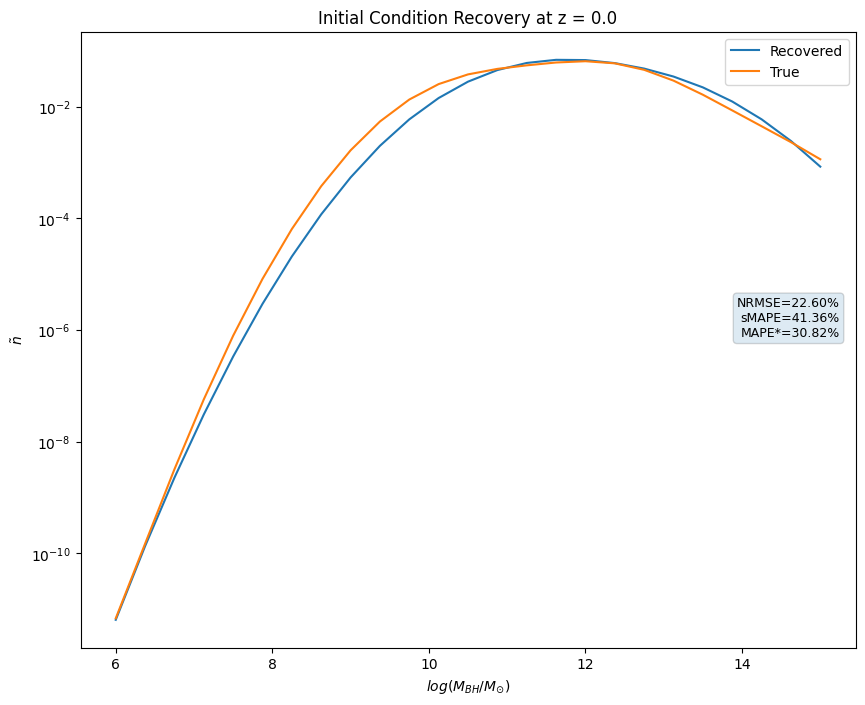

In [20]:
best_params = result.x
best_fun = result.fun


MODEL_PARAM_COUNT = 7
gaussian_parameters = best_params[:-MODEL_PARAM_COUNT]
model_parameters = best_params[-MODEL_PARAM_COUNT:]
parameters_observational = np.array([
        3.3e-02,
        8.2e-03,
        5.4e-02,
        1.07e+01,
        1.29e+01,
        1.21e+01,
        6.93e-01,
        1.05e+00,
        7.47e-01
    ])


grid_params = GridParameters(
    mbh_steps=mbh_steps,
    z_steps=mbh_steps*1000
)

ln_mbh_grid = np.linspace(
    grid_params.mbh_i,
    grid_params.mbh_f,
    grid_params.mbh_steps
)

initial_condition_recovered = gaussian_sum_from_p(
        gaussian_parameters,
        ln_mbh_grid,
        n_gauss=3
    )

# métricas robustas
nrmse = nrmse_percent(initial_condition, initial_condition_recovered, denom='mean')
s_mape = smape_percent(initial_condition, initial_condition_recovered, eps=1e-12)
stab_mape = stabilized_mape_percent(initial_condition, initial_condition_recovered, eps=1e-8)

metrics_text = (
    f'NRMSE={nrmse:.2f}%\n'
    f'sMAPE={s_mape:.2f}%\n'
    f'MAPE*={stab_mape:.2f}%'
)

plt.figure(figsize=(10,8))
plt.plot(ln_mbh_grid, initial_condition_recovered, label="Recovered")
plt.plot(ln_mbh_grid, initial_condition, label="True")
plt.xlabel(r'$log(M_{BH} / M_{\odot})$')
plt.ylabel(r'$\tilde{n}$')
plt.title(f"Initial Condition Recovery at z = {grid_params.z_f}")
plt.text(0.98, 0.50, metrics_text, transform=plt.gca().transAxes,
                    fontsize=9, va='bottom', ha='right',
                    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15))
plt.yscale("log")
plt.legend()
plt.show()
plt.close()

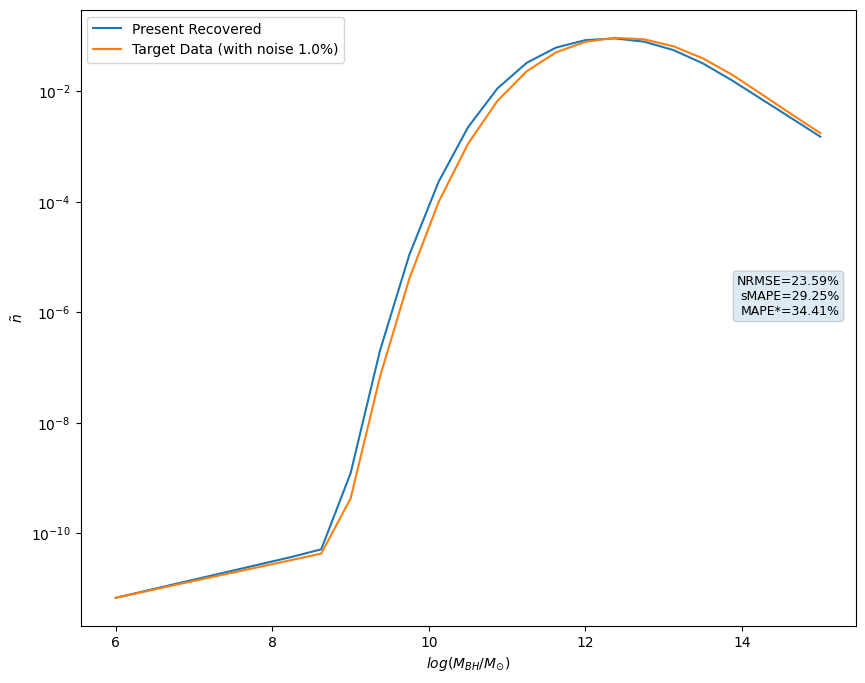

In [21]:
objective_function = ParametersRecoveryRemote.remote(
    grid_params=grid_params)

# Build physical model parameters
accretion_params = ParameterAccretionRate(
    # Bloco 2 -- Parametros da Luminosidade
    mbh_par=model_parameters[-MODEL_PARAM_COUNT] * 1e11,
    tau_par=model_parameters[-MODEL_PARAM_COUNT+1] * 1e9,
    alpha_par=model_parameters[-MODEL_PARAM_COUNT+2],

    # Bloco 3 -- Parametros da eficiencia Radiativa
    eta=model_parameters[-MODEL_PARAM_COUNT+3],
    t_q=model_parameters[-MODEL_PARAM_COUNT+4] * 1e9,
    b_1=model_parameters[-MODEL_PARAM_COUNT+5],
    b_2=model_parameters[-MODEL_PARAM_COUNT+6]
)

# ---- Generate target data ----

outputs = ray.get(
    objective_function.directly_problem.remote(
        initial_condition,
        accretion_params
    )
)


# métricas robustas
nrmse = nrmse_percent(target_data, outputs.n_final, denom='mean')
s_mape = smape_percent(target_data, outputs.n_final, eps=1e-12)
stab_mape = stabilized_mape_percent(target_data, outputs.n_final, eps=1e-8)

metrics_text = (
    f'NRMSE={nrmse:.2f}%\n'
    f'sMAPE={s_mape:.2f}%\n'
    f'MAPE*={stab_mape:.2f}%'
)

plt.figure(figsize=(10,8))
plt.plot(ln_mbh_grid, outputs.n_final, label="Present Recovered")
plt.plot(ln_mbh_grid,target_data, label=f"Target Data (with noise {noise_level*100:.1f}%)")
plt.xlabel(r'$log(M_{BH} / M_{\odot})$')
plt.ylabel(r'$\tilde{n}$')
plt.yscale("log")
plt.text(0.98, 0.50, metrics_text, transform=plt.gca().transAxes,
                    fontsize=9, va='bottom', ha='right',
                    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15))
plt.legend()
plt.show()
plt.close()

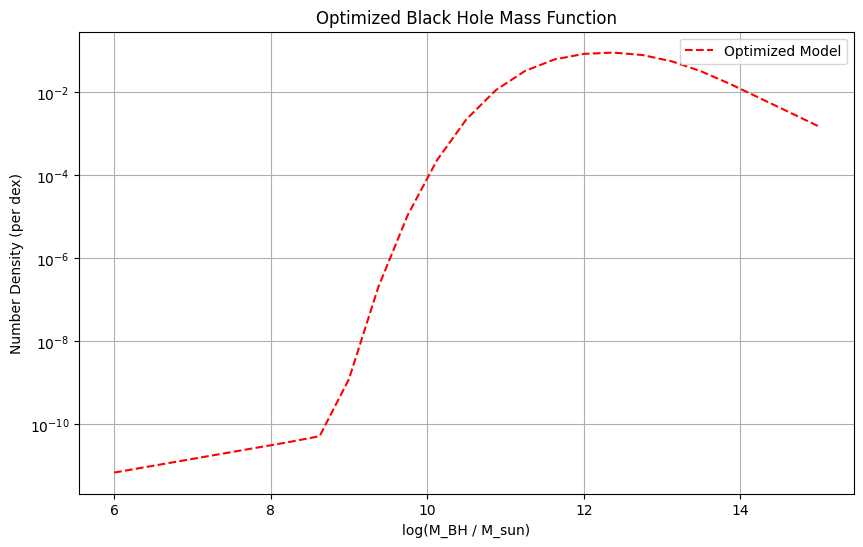

In [22]:
# === FIGURA 1 ===
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(
    outputs.ln_mbh_grid,
    outputs.n_final,
    label='Optimized Model',
    color='red',
    linestyle='--'
)
ax1.set_yscale('log')
ax1.set_xlabel('log(M_BH / M_sun)')
ax1.set_ylabel('Number Density (per dex)')
ax1.set_title('Optimized Black Hole Mass Function')
ax1.legend()
ax1.grid(True)



Metrics for Initial Condition Comparison:
NRMSE=22.60%
sMAPE=41.36%
MAPE*=30.82%
Metrics for Present Data Comparison:
NRMSE=23.59%
sMAPE=29.25%
MAPE*=34.41%


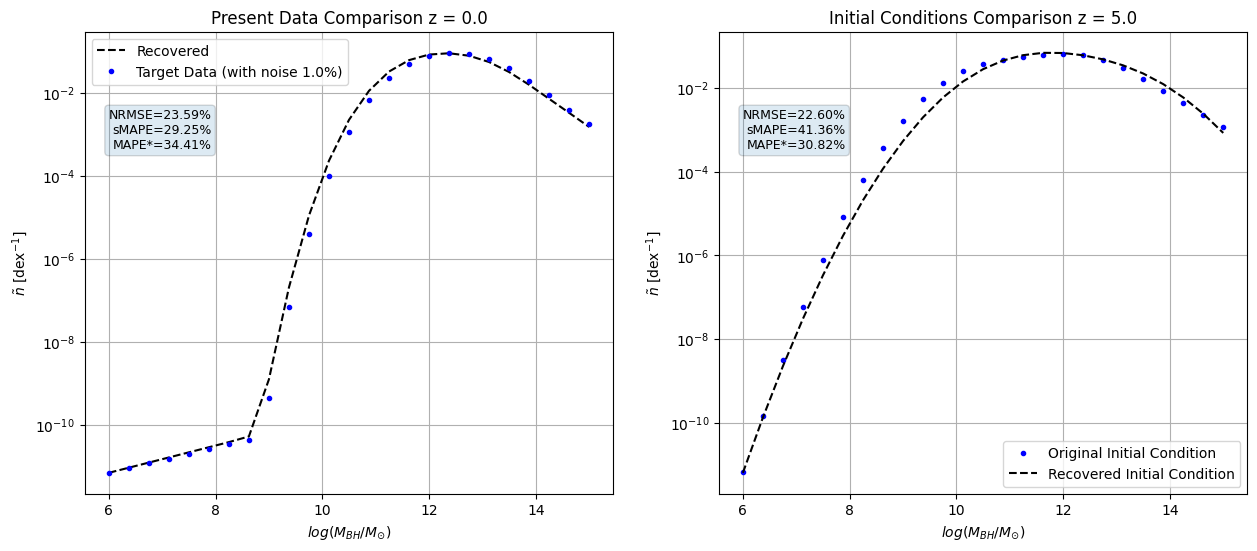

In [23]:

# === FIGURA 2 ===
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,6))
ax2.plot(
    outputs.ln_mbh_grid,
    initial_condition,
    '.',
    label='Original Initial Condition',
    color='blue'
)
ax2.plot(
    outputs.ln_mbh_grid,
    initial_condition_recovered,
    '--',
    label='Recovered Initial Condition',
    color='black',
)

# métricas robustas
nrmse = nrmse_percent(initial_condition, initial_condition_recovered, denom='mean')
s_mape = smape_percent(initial_condition, initial_condition_recovered, eps=1e-12)
stab_mape = stabilized_mape_percent(initial_condition, initial_condition_recovered, eps=1e-8)

metrics_text = (
    f'NRMSE={nrmse:.2f}%\n'
    f'sMAPE={s_mape:.2f}%\n'
    f'MAPE*={stab_mape:.2f}%'
)

print("Metrics for Initial Condition Comparison:")
print(metrics_text)

ax2.set_yscale('log')
ax2.set_xlabel(r'$log(M_{BH} / M_{\odot})$')
ax2.set_ylabel(r'$\tilde{n}$ [dex$^{-1}$]')

ax2.text(0.24, 0.74, metrics_text, transform=ax2.transAxes,
                    fontsize=9, va='bottom', ha='right',
                    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15))
ax2.set_title(f'Initial Conditions Comparison z = {grid_params.z_i}')
ax2.legend()
ax2.grid(True)


# métricas robustas
nrmse = nrmse_percent(target_data, outputs.n_final, denom='mean')
s_mape = smape_percent(target_data, outputs.n_final, eps=1e-12)
stab_mape = stabilized_mape_percent(target_data, outputs.n_final, eps=1e-8)

metrics_text = (
    f'NRMSE={nrmse:.2f}%\n'
    f'sMAPE={s_mape:.2f}%\n'
    f'MAPE*={stab_mape:.2f}%'
)

print("Metrics for Present Data Comparison:")
print(metrics_text)

ax1.plot(
    outputs.ln_mbh_grid,
    outputs.n_final,
    '--',
    label="Recovered",
    color='black'
)

ax1.plot(
    outputs.ln_mbh_grid,
    target_data,
    '.',
    label=f"Target Data (with noise {noise_level*100:.1f}%)",
    color='blue',
)

ax1.set_xlabel(r'$log(M_{BH} / M_{\odot})$')
ax1.set_ylabel(r'$\tilde{n}$ [dex$^{-1}$]')
ax1.set_yscale('log')
ax1.text(0.24, 0.74, metrics_text, transform=ax1.transAxes,
                    fontsize=9, va='bottom', ha='right',
                    bbox=dict(boxstyle="round,pad=0.3", alpha=0.15))
ax1.set_title(f'Present Data Comparison z = {grid_params.z_f}')
ax1.legend()
ax1.grid(True)

plt.show()

In [24]:
ray.shutdown()